In [ ]:
import importlib
import subprocess
import sys

def ensure_package(package_name, import_name=None):
    import_name = import_name or package_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"📦 Cài đặt thư viện: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

ensure_package("torch")
ensure_package("transformers")
ensure_package("tqdm")
ensure_package("pandas")
ensure_package("numpy")
ensure_package("scikit-learn", "sklearn")
ensure_package("matplotlib")
ensure_package("seaborn")
ensure_package("underthesea")

try:
    from vn_preprocessor import VNPreprocessor
except ImportError:
    print("❗Lỗi: Không tìm thấy `vn_preprocessor.py`. Vui lòng upload file này vào thư mục làm việc.")
    raise

try:
    from LDA_classifier import LDAClassifier
except ImportError:
    print("❗Lỗi: Không tìm thấy `LDA_classifier.py`. Vui lòng upload file này vào thư mục làm việc.")
    raise

try:
    from TFIDF_vectorlizer import TFIDFVectorizer
except ImportError:
    print("❗Lỗi: Không tìm thấy `TFIDF_vectorlizer.py`. Vui lòng upload file này vào thư mục làm việc.")
    raise


📦 Cài đặt thư viện: torch
📦 Cài đặt thư viện: transformers
📦 Cài đặt thư viện: matplotlib
📦 Cài đặt thư viện: seaborn


g:\UIT\do_an\Project_AI_Thinking\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Underthesea installed


In [3]:
import pandas as pd
import numpy as np
from vn_preprocessor import VNPreprocessor
from datasets import load_dataset
from LDA_classifier import LDAClassifier
from TFIDF_vectorlizer import TFIDFVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns
from phoBERT_classifier import PhoBERTSentimentClassifier

Load dataset

In [4]:
ds = load_dataset(
    "uitnlp/vietnamese_students_feedback", revision="refs/convert/parquet"
)

Chia dataset thành 3 tập train, validation và test

In [5]:
df_train = pd.DataFrame(ds["train"][:])
df_val = pd.DataFrame(ds["validation"][:])
df_test = pd.DataFrame(ds["test"][:])

prep = VNPreprocessor(
    text_col="sentence",
    analyzer="word",
    use_underthesea=True,
    add_clean=True,
    add_no_stop=True,
    add_tokens=False,
    add_lengths=True,
)

prep_raw = VNPreprocessor(
    text_col="sentence",
    analyzer="word",
    use_underthesea=False,
    add_clean=True,
    add_no_stop=True,
    add_tokens=False,
    add_lengths=True,
)

Transform data

In [ ]:
# transform với data raw
df_raw_train = prep_raw.transform(df_train)
df_raw_val = prep_raw.transform(df_val)
df_raw_test = prep_raw.transform(df_test)

# transform với Underthesea
df_underthesea_train = prep.transform(df_train)
df_underthesea_val = prep.transform(df_val)
df_underthesea_test = prep.transform(df_test)


Tập train
Tập validate
Tập test


,sentence,sentiment,topic
0,nói tiếng anh lưu loát .,2,0
1,giáo viên rất vui tính .,2,0
2,cô max có tâm .,2,0
3,"giảng bài thu hút , dí dỏm .",2,0
4,"giáo viên không giảng dạy kiến thức , hướng dẫ...",0,0


In [9]:
print('Tập train')
df_train.head()

Tập train


,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0


In [10]:
print('Tập validate')
df_val.head()

Tập validate


,sentence,sentiment,topic
0,giáo trình chưa cụ thể .,0,1
1,giảng buồn ngủ .,0,0
2,"giáo viên vui tính , tận tâm .",2,0
3,"giảng viên nên giao bài tập nhiều hơn , chia n...",0,0
4,"giảng viên cần giảng bài chi tiết hơn , đi sâu...",0,0


In [11]:
print('Tập test')
df_test.head()

Tập test


,sentence,sentiment,topic
0,nói tiếng anh lưu loát .,2,0
1,giáo viên rất vui tính .,2,0
2,cô max có tâm .,2,0
3,"giảng bài thu hút , dí dỏm .",2,0
4,"giáo viên không giảng dạy kiến thức , hướng dẫ...",0,0


Vectorize dataset

In [12]:
vectorlizer = TFIDFVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
)

## vectorlizer cho tập train
df_underthesea_train = vectorlizer.fit_transform(
    df_underthesea_train, text_column="sentence_nostop", new_column="vector"
)
df_raw_train = vectorlizer.transform(
    df_raw_train, text_column="sentence_nostop", new_column="vector"
)

# Ghép thành DataFrame
df_display = pd.DataFrame(
    {
        "Raw sentence": df_raw_train["sentence_nostop"],
        "Underthesea sentence": df_underthesea_train["sentence_nostop"],
    }
)

df_vectorized_display = pd.DataFrame(
    {
        "Raw vector": df_raw_train["vector"],
        "Underthesea vector": df_underthesea_train["vector"],
    }
)

print("DataFrame hiển thị:")
print(df_display.head())
print("DataFrame vectorized hiển thị:")
print(df_vectorized_display.head())

## vectorlizer cho tập test
df_raw_test = vectorlizer.transform(
    df_raw_test, text_column="sentence_nostop", new_column="vector"
)
df_underthesea_test = vectorlizer.transform(
    df_underthesea_test, text_column="sentence_nostop", new_column="vector"
)

DataFrame hiển thị:
                                        Raw sentence  \
0                            slide giáo trình đầy đủ   
1             nhiệt tình giảng dạy gần gũi sinh viên   
2                 đi học đầy đủ full điểm chuyên cần   
3  chưa áp dụng công nghệ thông tin thiết bị hỗ t...   
4           thầy giảng bài có bài tập ví dụ ngay lớp   

                                Underthesea sentence  
0                            slide giáo_trình đầy_đủ  
1             nhiệt_tình giảng_dạy gần_gũi sinh_viên  
2                 đi học đầy_đủ full_điểm chuyên cần  
3  chưa áp_dụng công_nghệ_thông_tin thiết_bị hỗ_t...  
4           thầy giảng bài có bài_tập ví_dụ ngay lớp  
DataFrame vectorized hiển thị:
                                          Raw vector  \
0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
1  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
3  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
4 

LDA Classifier

In [13]:
### LDA Classifier
raw_lda_classifier = LDAClassifier(solver="svd")
underthesea_lda_classifier = LDAClassifier(solver="svd")


Train model

In [14]:
# # Train model
raw_lda_classifier.fit(
    np.array(df_raw_train["vector"].tolist()),
    np.array(df_raw_train["sentiment"].tolist()),
)
underthesea_lda_classifier.fit(
    np.array(df_underthesea_train["vector"].tolist()),
    np.array(df_underthesea_train["sentiment"].tolist()),
)
print("Model đã được train thành công.")

Model đã được train thành công.


Dự đoán và đánh giá mô hình

In [15]:
### Dự đoán và đánh giá mô hình
## RAW
raw_actual = df_raw_test["sentiment"]
raw_accuracy = raw_lda_classifier.score(
    np.array(df_raw_test["vector"].tolist()), raw_actual
)

## UNDERTHESEA
underthesea_actual = df_underthesea_test["sentiment"]
underthesea_accuracy = underthesea_lda_classifier.score(
    np.array(df_underthesea_test["vector"].tolist()), underthesea_actual
)

So sánh độ chính xác của mô hình không sử dụng Underthesea và có sử dụng Underthesea

In [16]:
print(f"Độ chính xác của mô hình trên tập test không underthesea: {raw_accuracy:.2f}")
print(f"Độ chính xác của mô hình trên tập test có underthesea: {underthesea_accuracy :.2f}")

Độ chính xác của mô hình trên tập test không underthesea: 0.84
Độ chính xác của mô hình trên tập test có underthesea: 0.81


Classification Report

In [17]:
sentiment_labels = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
# 4. Classification Report
print("\nClassification Report (Raw Data):")
raw_pred = raw_lda_classifier.predict(np.array(df_raw_test["vector"].tolist()))
print(classification_report(raw_actual, raw_pred, target_names=sentiment_labels))

print("\nClassification Report (Underthesea Data):")
underthesea_pred = underthesea_lda_classifier.predict(np.array(df_underthesea_test["vector"].tolist()))
print(classification_report(underthesea_actual, underthesea_pred, target_names=sentiment_labels))



Classification Report (Raw Data):
              precision    recall  f1-score   support

    NEGATIVE       0.86      0.86      0.86      1409
     NEUTRAL       0.29      0.25      0.27       167
    POSITIVE       0.87      0.89      0.88      1590

    accuracy                           0.84      3166
   macro avg       0.68      0.66      0.67      3166
weighted avg       0.84      0.84      0.84      3166


Classification Report (Underthesea Data):
              precision    recall  f1-score   support

    NEGATIVE       0.84      0.82      0.83      1409
     NEUTRAL       0.22      0.26      0.24       167
    POSITIVE       0.87      0.87      0.87      1590

    accuracy                           0.81      3166
   macro avg       0.64      0.65      0.64      3166
weighted avg       0.82      0.81      0.82      3166



Confusion Matrix


Confusion Matrix (Raw Data):


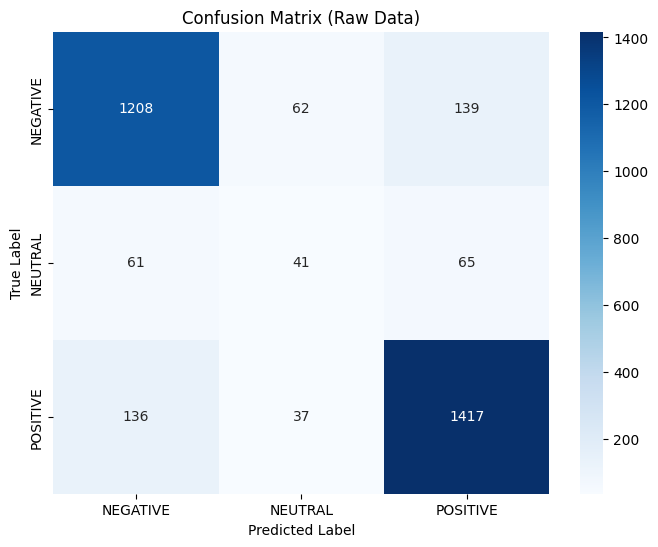


Confusion Matrix (Underthesea Data):


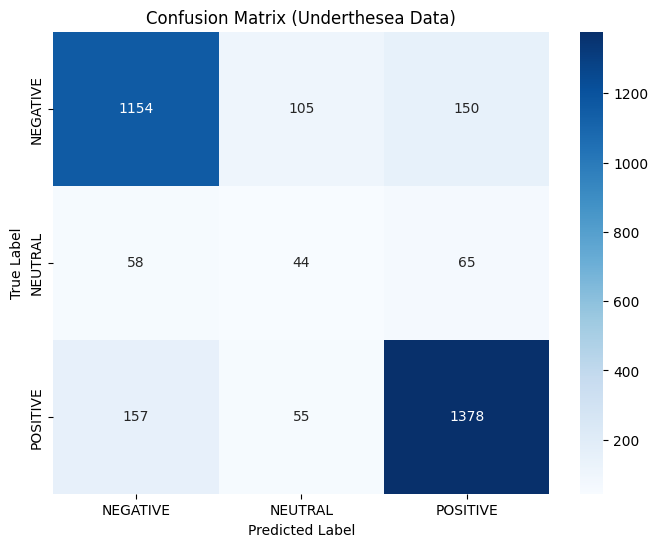

In [18]:
# 5. Confusion Matrix
print("\nConfusion Matrix (Raw Data):")
cm_raw = confusion_matrix(raw_actual, raw_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_labels, yticklabels=sentiment_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Raw Data)')
plt.show()

print("\nConfusion Matrix (Underthesea Data):")
cm_underthesea = confusion_matrix(underthesea_actual, underthesea_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_underthesea, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_labels, yticklabels=sentiment_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Underthesea Data)')
plt.show()

Với PhoBERT

In [ ]:
from phoBERT_classifier import PhoBERTSentimentClassifier

In [ ]:
clf = PhoBERTSentimentClassifier(batch_size=16, lr=2e-5, max_len=128)
clf.prepare_dataloader(df_train, df_val, df_test)
clf.train(epochs=3)

metrics = clf.evaluate_on_test(return_report=True)
print("Accuracy:", metrics["accuracy"])
print(metrics["text_report"])       # Báo cáo dạng sklearn
print(metrics["confusion_matrix"])  # Ma trận nhầm lẫn (numpy array)

y_true = metrics["y_true"]
y_pred_phobert = metrics["y_pred"]

Lưu lại model

In [ ]:
clf.save_model("./phobert_sentiment")

Load lại model PhoBERT

In [ ]:
clf = PhoBERTSentimentClassifier()

clf.load_model("./phobert_sentiment")

Dùng model để dự đoán

In [ ]:
text = input("Nhập câu cần phân tích cảm xúc: ")
label = clf.predict(text)
print("Dự đoán:", label_map[label])
